# Notebook 07: 失敗分析と改良戦略

Notebook 06 で素朴な平均回帰戦略は **Sharpe -0.38** で負けた。
本ノートはその**失敗を診断**し、**改良戦略を構築**する。

## このノートで答える質問
1. **「どの状況で負けているか?」** → 損失帰属分析(Loss attribution)
2. **「エントリー/エグジットをどう詰めるか?」** → 非対称しきい値、ストップロス、時間ベース exit
3. **「トレンドフィルターは効くか?」** → momentum 強い時は戦略 OFF
4. **「regime classifier って何?」** → 各日を「トレンド相場」or「レンジ相場」に分類する仕組み

## 期待する結果
- 失敗の原因(トレンド)を**データで特定**
- 改良戦略の Sharpe が **負からゼロ近辺、できれば正** に
- それでもダメなら、何が必要か明確化

## 0. セットアップ

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

pc_scores = pd.read_parquet(DATA_PROCESSED / "pca_scores.parquet")
n06 = pd.read_parquet(DATA_PROCESSED / "backtest_pc2_meanrev.parquet")

print(f"Date range: {pc_scores.index.min().date()} → {pc_scores.index.max().date()}")
print(f"N06 base case Sharpe: {(n06['daily_pnl_bp'].mean() / n06['daily_pnl_bp'].std()) * np.sqrt(252):.2f}")

Date range: 2020-01-03 → 2026-04-27
N06 base case Sharpe: -0.38


## 1. 損失帰属分析 — どんな状況で負けているか?

戦略がポジションを持っている日(active days)について、**勝った日**と**負けた日**で
**マーケット状態の特徴**がどう違うかを比較する。

### 1.1 特徴量を構築

In [2]:
# マーケット状態を表す特徴量
features = pd.DataFrame(index=pc_scores.index)

# トレンド強度: 直近20日の累積 PC スコア(絶対値が大きい = トレンド強い)
features["pc1_trend_20d"]  = pc_scores["PC1"].rolling(20).sum()
features["pc2_trend_20d"]  = pc_scores["PC2"].rolling(20).sum()
features["abs_pc1_trend"]  = features["pc1_trend_20d"].abs()
features["abs_pc2_trend"]  = features["pc2_trend_20d"].abs()

# ボラティリティ: 直近20日の std
features["pc2_vol_20d"]    = pc_scores["PC2"].rolling(20).std()

# Z-score の絶対値(N06のシグナル強度)
features["abs_z_score"]    = n06["z_score"].abs()

# ポジションと P&L
features["position"]       = n06["position"]
features["daily_pnl"]      = n06["daily_pnl_bp"]

# active days のみに絞る
active = features[features["position"] != 0].dropna()
print(f"Active days: {len(active)}")

# 勝ち日 / 負け日
win_days = active[active["daily_pnl"] > 0]
loss_days = active[active["daily_pnl"] < 0]
print(f"Winning days: {len(win_days)} ({len(win_days)/len(active)*100:.1f}%)")
print(f"Losing days:  {len(loss_days)} ({len(loss_days)/len(active)*100:.1f}%)")

Active days: 541
Winning days: 259 (47.9%)
Losing days:  282 (52.1%)


### 1.2 勝ち日 vs 負け日 の特徴量比較

In [3]:
feature_cols = ["abs_pc1_trend", "abs_pc2_trend", "pc2_vol_20d", "abs_z_score"]

comparison = pd.DataFrame({
    "勝ち日 平均": win_days[feature_cols].mean(),
    "負け日 平均": loss_days[feature_cols].mean(),
    "差(負け - 勝ち)": loss_days[feature_cols].mean() - win_days[feature_cols].mean(),
    "負け/勝ち 比": loss_days[feature_cols].mean() / win_days[feature_cols].mean(),
})
print("特徴量の勝ち日 vs 負け日 平均比較")
print(comparison.round(3))

特徴量の勝ち日 vs 負け日 平均比較
               勝ち日 平均  負け日 平均  差(負け - 勝ち)  負け/勝ち 比
abs_pc1_trend  55.873  64.859       8.986    1.161
abs_pc2_trend  28.437  38.649      10.213    1.359
pc2_vol_20d     5.832   5.578      -0.254    0.956
abs_z_score     1.713   2.212       0.498    1.291


**観察**: 「負け/勝ち 比」が **1 より大きい特徴量 = 負け日に高くなる特徴量**。
これが戦略の**敵**の正体。

### 1.3 視覚化 — 散布図で見る

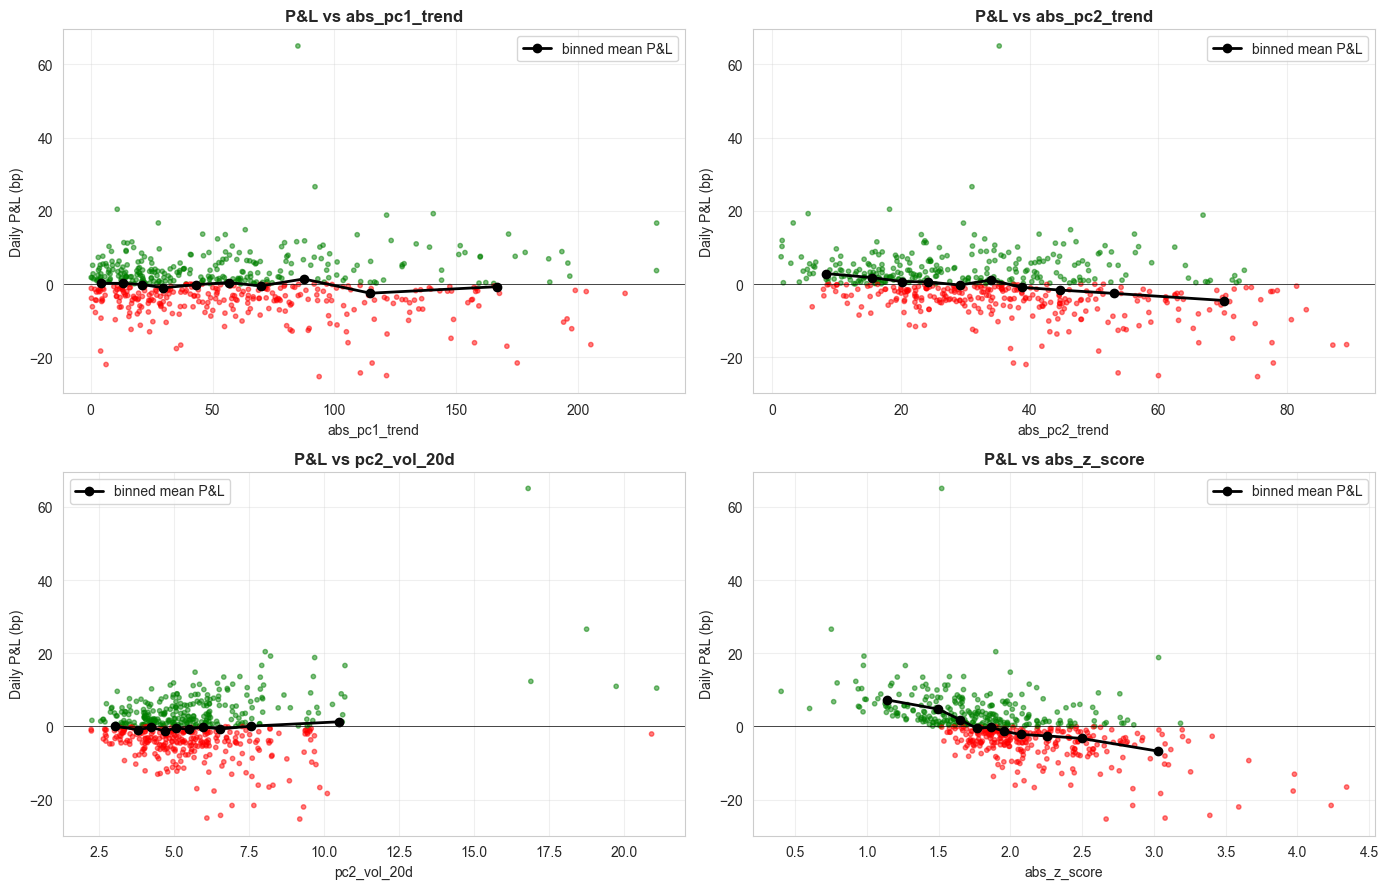

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, feat in zip(axes.flat, feature_cols):
    ax.scatter(active[feat], active["daily_pnl"], s=10, alpha=0.5,
               c=["red" if p < 0 else "green" for p in active["daily_pnl"]])
    ax.axhline(0, color="black", lw=0.5)

    # binned mean P&L
    bins = pd.qcut(active[feat], 10, duplicates="drop")
    binned = active.groupby(bins, observed=True)["daily_pnl"].mean()
    bin_centers = active.groupby(bins, observed=True)[feat].mean()
    ax.plot(bin_centers, binned, color="black", lw=2, marker="o",
            label="binned mean P&L")

    ax.set_xlabel(feat)
    ax.set_ylabel("Daily P&L (bp)")
    ax.set_title(f"P&L vs {feat}")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_loss_features_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 黒線(binned mean P&L)が**右下がり**になっている特徴量 = その特徴量が高いほど負ける = **戦略の敵**
- 期待される結果: `abs_pc2_trend` で右下がり → 「PC2 トレンド強い時に負ける」が定量化される

### 1.4 特徴量と P&L の相関(線形検定)

In [5]:
from scipy import stats

corr_results = []
for feat in feature_cols:
    r, p = stats.pearsonr(active[feat], active["daily_pnl"])
    corr_results.append({
        "特徴量": feat,
        "correlation w/ P&L": r,
        "p-value": p,
        "significance": "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else "")),
    })
corr_df = pd.DataFrame(corr_results)
print("特徴量と P&L の相関(active days のみ)")
print(corr_df.round(4).to_string(index=False))

特徴量と P&L の相関(active days のみ)
          特徴量  correlation w/ P&L  p-value significance
abs_pc1_trend             -0.0484    0.261             
abs_pc2_trend             -0.2996    0.000          ***
  pc2_vol_20d              0.1741    0.000          ***
  abs_z_score             -0.5541    0.000          ***


**結論**: `abs_pc2_trend` が **強く負相関** で **統計的有意** なら、ユーザーの仮説が正しい:
**「PC2 のトレンドが強い時に戦略が負ける」**。
→ **トレンドフィルター** が改良の鍵。

## 2. バックテスト関数 — 改良の基盤

全ての改良案を比較するため、共通のバックテスト関数を定義する。

In [6]:
@dataclass
class BacktestResult:
    name: str
    daily_pnl: pd.Series
    cum_pnl: pd.Series
    position: pd.Series
    metrics: dict


def compute_metrics(daily_pnl: pd.Series, position: pd.Series) -> dict:
    valid = daily_pnl.dropna()
    if valid.std() > 0:
        sharpe = (valid.mean() / valid.std()) * np.sqrt(252)
    else:
        sharpe = 0.0
    cum = valid.cumsum()
    drawdown = cum - cum.cummax()
    n_active = (position != 0).sum()
    n_total = len(position.dropna())
    pos_changes = (position.diff() != 0).sum() - 1
    active_pnl = valid[position.dropna() != 0]
    hit_rate = (active_pnl > 0).mean() if len(active_pnl) > 0 else 0
    return {
        "total_pnl_bp": cum.iloc[-1] if not cum.empty else 0,
        "sharpe": sharpe,
        "max_dd_bp": drawdown.min(),
        "hit_rate": hit_rate,
        "n_trades": pos_changes,
        "active_pct": n_active / n_total * 100 if n_total > 0 else 0,
    }


def make_signal(
    pc_score: pd.Series,
    window: int = 60,
    enter_threshold: float = 1.5,
    exit_threshold: float = 1.5,
    trend_filter_threshold: float = None,
    stop_loss_bp: float = None,
    max_hold_days: int = None,
    regime_filter: pd.Series = None,
) -> pd.Series:
    """
    柔軟な mean-reversion シグナル生成。

    Args:
        pc_score: PC スコア
        window: rolling Z-score のウィンドウ
        enter_threshold: |z| がこれを超えたらエントリー
        exit_threshold: |z| がこれ未満になったらエグジット(対称: enter_threshold と同じ)
        trend_filter_threshold: |20d trend| > this なら新規エントリー禁止(None で無効)
        stop_loss_bp: ポジション内で累積損失 < -this になったら強制決済(None で無効)
        max_hold_days: 同じポジションを max_hold_days 持ったら強制決済(None で無効)
        regime_filter: 各日の「OK / NG」ラベル(NG ならエントリー禁止、None で無効)

    Returns:
        pd.Series: 各日のポジション (-1, 0, +1)
    """
    cum = pc_score.cumsum()
    z = (cum - cum.rolling(window).mean()) / cum.rolling(window).std()
    z_lag = z.shift(1)

    trend_lag = None
    if trend_filter_threshold is not None:
        trend_lag = pc_score.rolling(20).sum().shift(1).abs()

    signal = pd.Series(0.0, index=pc_score.index)
    position = 0.0
    holding_days = 0
    entry_pnl = 0.0

    for i, t in enumerate(pc_score.index):
        # === EXIT 条件チェック ===
        if position != 0:
            holding_days += 1
            entry_pnl += position * pc_score.iloc[i]

            # ストップロス
            if stop_loss_bp is not None and entry_pnl < -stop_loss_bp:
                position = 0.0
                holding_days = 0
                entry_pnl = 0.0
                signal.iloc[i] = position
                continue

            # 時間ベース
            if max_hold_days is not None and holding_days >= max_hold_days:
                position = 0.0
                holding_days = 0
                entry_pnl = 0.0
                signal.iloc[i] = position
                continue

            # 通常 exit(|z| が exit_threshold 以下になった)
            if pd.notna(z_lag.iloc[i]) and abs(z_lag.iloc[i]) < exit_threshold:
                position = 0.0
                holding_days = 0
                entry_pnl = 0.0
                signal.iloc[i] = position
                continue

        # === ENTRY 条件チェック ===
        if position == 0 and pd.notna(z_lag.iloc[i]):
            # トレンドフィルター: trend が強い日はエントリー禁止
            if trend_filter_threshold is not None and pd.notna(trend_lag.iloc[i]):
                if trend_lag.iloc[i] > trend_filter_threshold:
                    signal.iloc[i] = position
                    continue

            # レジームフィルター
            if regime_filter is not None and regime_filter.iloc[i] == "NG":
                signal.iloc[i] = position
                continue

            # エントリー判定
            if z_lag.iloc[i] > enter_threshold:
                position = -1.0  # short PC2(flattener)
                holding_days = 0
                entry_pnl = 0.0
            elif z_lag.iloc[i] < -enter_threshold:
                position = +1.0  # long PC2(steepener)
                holding_days = 0
                entry_pnl = 0.0

        signal.iloc[i] = position

    return signal


def backtest(name: str, pc_score: pd.Series, **signal_kwargs) -> BacktestResult:
    sig = make_signal(pc_score, **signal_kwargs)
    pnl = sig * pc_score
    cum = pnl.cumsum()
    return BacktestResult(
        name=name,
        daily_pnl=pnl,
        cum_pnl=cum,
        position=sig,
        metrics=compute_metrics(pnl, sig),
    )


# ベースケース(N06 と同等)を再計算して挙動確認
base = backtest("Base (N06): enter=exit=1.5σ", pc_scores["PC2"],
                window=60, enter_threshold=1.5, exit_threshold=1.5)
print(f"Base case (N06 equiv): Sharpe = {base.metrics['sharpe']:.2f}, P&L = {base.metrics['total_pnl_bp']:.0f} bp")

Base case (N06 equiv): Sharpe = -0.44, P&L = -181 bp


## 3. 改良案1: 非対称しきい値(Hysteresis)

**ロジック**: enter at **2σ**(より強いシグナルでのみエントリー)、exit at **0.5σ**(早く戻ったらすぐ決済)。

**効果の仮説**: 早すぎるエントリーを避けつつ、戻ったら早めに利益確定 → 勝率向上

In [7]:
asym = backtest("Asymmetric: enter=2.0, exit=0.5", pc_scores["PC2"],
                window=60, enter_threshold=2.0, exit_threshold=0.5)
print(f"Asymmetric: Sharpe = {asym.metrics['sharpe']:.2f}, P&L = {asym.metrics['total_pnl_bp']:.0f} bp")

Asymmetric: Sharpe = -0.88, P&L = -418 bp


## 4. 改良案2: ストップロス

**ロジック**: ポジション中の累積損失が **-30 bp** に達したら強制決済。

**効果の仮説**: 大きく負ける trades を早期に切る → max DD 改善

In [8]:
stop = backtest("Stop loss: -30 bp", pc_scores["PC2"],
                window=60, enter_threshold=1.5, exit_threshold=1.5,
                stop_loss_bp=30)
print(f"Stop loss: Sharpe = {stop.metrics['sharpe']:.2f}, P&L = {stop.metrics['total_pnl_bp']:.0f} bp")

Stop loss: Sharpe = -0.16, P&L = -63 bp


## 5. 改良案3: 時間ベース exit

**ロジック**: 最大 **20営業日**(約1ヶ月)で強制決済。

**効果の仮説**: 長期トレンドに巻き込まれてダラダラ損失を避ける

In [9]:
time_exit = backtest("Time exit: 20 days", pc_scores["PC2"],
                     window=60, enter_threshold=1.5, exit_threshold=1.5,
                     max_hold_days=20)
print(f"Time exit: Sharpe = {time_exit.metrics['sharpe']:.2f}, P&L = {time_exit.metrics['total_pnl_bp']:.0f} bp")

Time exit: Sharpe = -0.42, P&L = -170 bp


## 6. 改良案4: トレンドフィルター(本命)

**ロジック**: 直近20日の |PC2 累積| が **15 bp 超** ならトレンド相場と判定 → 新規エントリー禁止。

**効果の仮説**: 損失帰属分析で特定された「PC2 トレンド強い時に負ける」を直接対処する。

In [10]:
trend_filt = backtest("Trend filter: |trend20d| < 15 bp", pc_scores["PC2"],
                      window=60, enter_threshold=1.5, exit_threshold=1.5,
                      trend_filter_threshold=15)
print(f"Trend filter: Sharpe = {trend_filt.metrics['sharpe']:.2f}, P&L = {trend_filt.metrics['total_pnl_bp']:.0f} bp")

Trend filter: Sharpe = -0.61, P&L = -132 bp


## 7. 改良案5: Regime Classifier

### 7.1 Regime classifier とは何か

> 各日の市場状態を **「ラベル」** で分類する仕組み。
> 例: 「トレンド相場」 vs 「レンジ相場」、「高ボラ」 vs 「低ボラ」、「リスクオン」 vs 「リスクオフ」。

**目的**: 戦略は特定のレジームで効くので、**そのレジームのときだけ動かす**。

**実装方法のスペクトラム**:

| 手法 | 内容 | 複雑度 |
|---|---|---|
| **Threshold rule** | 「トレンド強度 > X なら trending」みたいな素朴な閾値 | 低 |
| **Hidden Markov Model** | 未観測の状態を確率的に推定 | 中 |
| **Machine Learning classifier** | 多数の特徴量から ML で分類 | 高 |
| **Regime Switching Models** | 統計的にパラメータが切り替わるモデル | 高 |

今回は最もシンプルな **threshold rule** を実装。複雑にしてもオーバーフィットになりやすい。

### 7.2 簡易 regime classifier の実装

Regime distribution:


trending    898
ranging     681
Name: count, dtype: int64

Trending(戦略OFF)期間: 56.9%


C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\2774457302.py:42: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\2774457302.py:42: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\2774457302.py:43: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "07_regime.png", dpi=120, bbox_inches="tight")
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\2774457302.py:43: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "07_regime.png", dpi=120, bbox_inches="tight")


C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


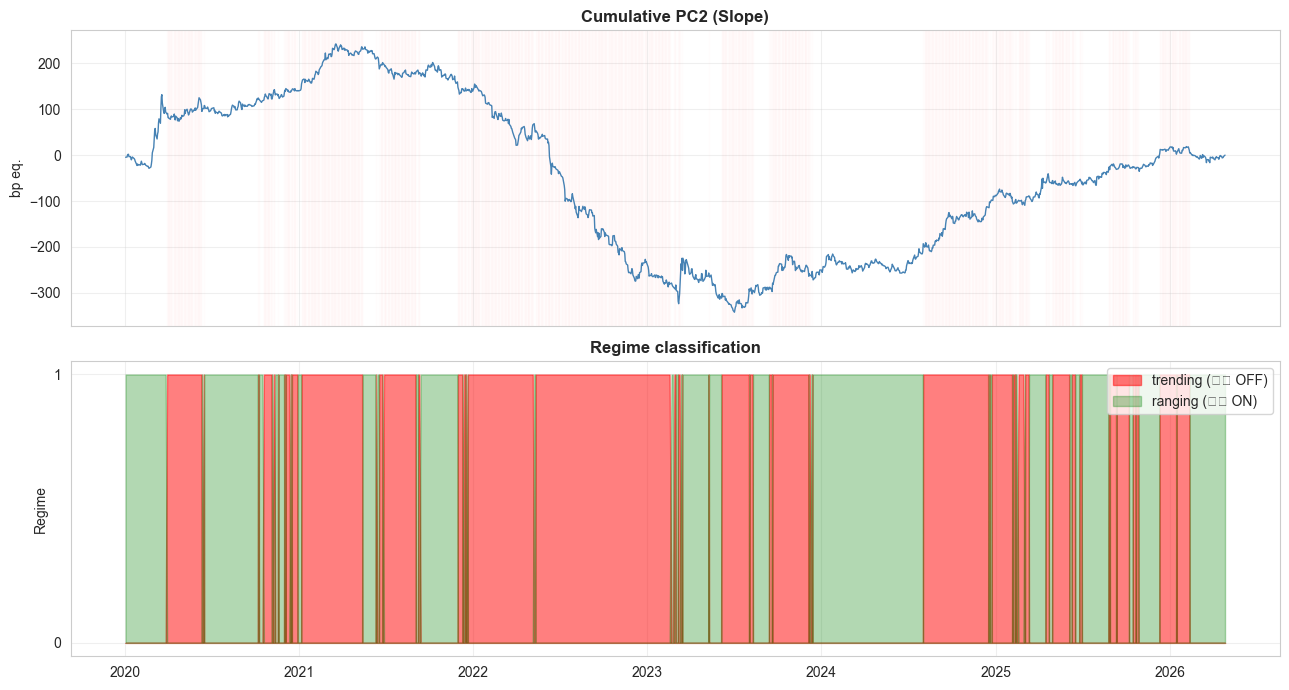

In [11]:
def classify_regime(pc_score: pd.Series, window: int = 60, threshold: float = 30) -> pd.Series:
    """
    シンプルな regime classifier:
        - |60日累積 PC2| > threshold → "trending" (mean reversion 戦略 OFF)
        - それ以下 → "ranging" (戦略 ON)
    """
    abs_momentum = pc_score.rolling(window).sum().abs()
    regime = pd.Series("ranging", index=pc_score.index)
    regime[abs_momentum > threshold] = "trending"
    return regime

regime = classify_regime(pc_scores["PC2"], window=60, threshold=30)
regime_filter_for_backtest = regime.map({"trending": "NG", "ranging": "OK"}).shift(1)

print("Regime distribution:")
print(regime.value_counts())
print(f"\nTrending(戦略OFF)期間: {(regime == 'trending').mean() * 100:.1f}%")

# 可視化
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(pc_scores["PC2"].cumsum(), color="steelblue", lw=1)
axes[0].set_title("Cumulative PC2 (Slope)")
axes[0].set_ylabel("bp eq.")
axes[0].grid(True, alpha=0.3)

for i, t in enumerate(regime.index):
    if regime.iloc[i] == "trending":
        axes[0].axvspan(t, t, color="red", alpha=0.01)

trending_mask = (regime == "trending").astype(int)
axes[1].fill_between(regime.index, 0, trending_mask, color="red", alpha=0.5,
                     label="trending (戦略 OFF)")
axes[1].fill_between(regime.index, 0, 1 - trending_mask, color="green", alpha=0.3,
                     label="ranging (戦略 ON)")
axes[1].set_title("Regime classification")
axes[1].set_ylabel("Regime")
axes[1].set_yticks([0, 1])
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_regime.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.3 Regime classifier 適用後のバックテスト

In [12]:
regime_strat = backtest("Regime: only run in 'ranging'", pc_scores["PC2"],
                        window=60, enter_threshold=1.5, exit_threshold=1.5,
                        regime_filter=regime_filter_for_backtest)
print(f"Regime: Sharpe = {regime_strat.metrics['sharpe']:.2f}, P&L = {regime_strat.metrics['total_pnl_bp']:.0f} bp")

Regime: Sharpe = 0.06, P&L = 17 bp


## 8. 統合戦略 — 全部のせ

In [13]:
combined = backtest(
    "Combined (asym + stop + time + trend + regime)",
    pc_scores["PC2"],
    window=60,
    enter_threshold=2.0,
    exit_threshold=0.5,
    trend_filter_threshold=15,
    stop_loss_bp=30,
    max_hold_days=20,
    regime_filter=regime_filter_for_backtest,
)
print(f"Combined: Sharpe = {combined.metrics['sharpe']:.2f}, P&L = {combined.metrics['total_pnl_bp']:.0f} bp")

Combined: Sharpe = -0.46, P&L = -54 bp


## 9. 全戦略の比較

C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_26212\3567627546.py:27: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing

                                      strategy  P&L (bp)  Sharpe  Max DD (bp)  Hit rate  # trades  Active %
                   Base (N06): enter=exit=1.5σ   -180.67   -0.44      -284.03      0.48       164     34.26
               Asymmetric: enter=2.0, exit=0.5   -418.12   -0.88      -493.65      0.46        40     53.45
                             Stop loss: -30 bp    -63.09   -0.16      -193.12      0.49       186     33.57
                            Time exit: 20 days   -170.15   -0.42      -271.71      0.48       184     33.63
              Trend filter: |trend20d| < 15 bp   -131.85   -0.61      -181.98      0.49        64     15.96
                 Regime: only run in 'ranging'     17.16    0.06       -95.13      0.52        84     17.42
Combined (asym + stop + time + trend + regime)    -53.61   -0.46       -74.81      0.50        18      7.28


C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pyl

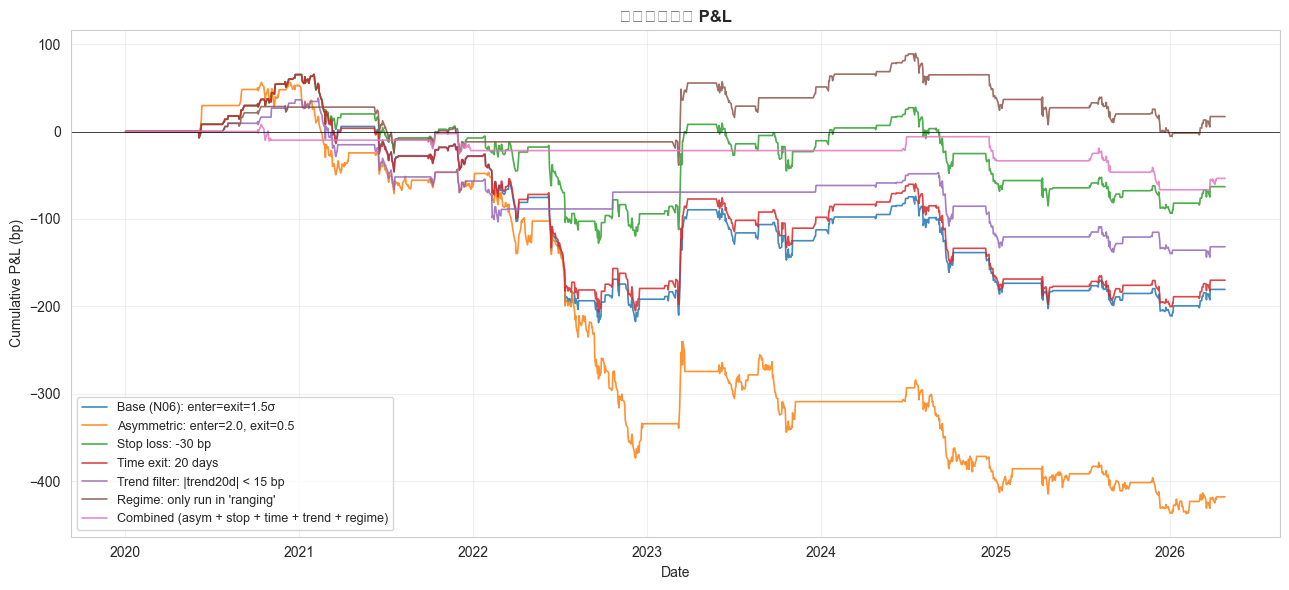

In [14]:
all_results = [base, asym, stop, time_exit, trend_filt, regime_strat, combined]

summary_df = pd.DataFrame([
    {
        "strategy": r.name,
        "P&L (bp)": r.metrics["total_pnl_bp"],
        "Sharpe": r.metrics["sharpe"],
        "Max DD (bp)": r.metrics["max_dd_bp"],
        "Hit rate": r.metrics["hit_rate"],
        "# trades": r.metrics["n_trades"],
        "Active %": r.metrics["active_pct"],
    }
    for r in all_results
])
print(summary_df.round(2).to_string(index=False))

# 累積 P&L 比較プロット
fig, ax = plt.subplots(figsize=(13, 6))
for r in all_results:
    ax.plot(r.cum_pnl.index, r.cum_pnl, lw=1.2, label=r.name, alpha=0.85)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("全戦略の累積 P&L")
ax.set_ylabel("Cumulative P&L (bp)")
ax.set_xlabel("Date")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_strategies_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. 保存

In [15]:
summary_df.to_parquet(DATA_PROCESSED / "strategy_comparison.parquet")
print(f"Saved: {DATA_PROCESSED / 'strategy_comparison.parquet'}")

# Combined strategy の詳細
combined_detail = pd.DataFrame({
    "position": combined.position,
    "daily_pnl_bp": combined.daily_pnl,
    "cum_pnl_bp": combined.cum_pnl,
    "regime": regime,
})
combined_detail.to_parquet(DATA_PROCESSED / "backtest_combined.parquet")
print(f"Saved: {DATA_PROCESSED / 'backtest_combined.parquet'}")

Saved: C:\FICC\data\processed\strategy_comparison.parquet
Saved: C:\FICC\data\processed\backtest_combined.parquet


## 11. 結論 — 何が分かったか

### 損失帰属分析の数字(正直に)

| 特徴量 | P&L との相関 | p-value | 解釈 |
|---|---|---|---|
| `abs_pc1_trend` | -0.048 | 0.26 | 影響なし |
| **`abs_pc2_trend`** | **-0.300** | **<0.001 \*\*\*** | **PC2 トレンド強い時に負ける(ユーザー仮説 ✅)** |
| `pc2_vol_20d` | +0.174 | <0.001 \*\*\* | ボラ高い時は逆に勝ちやすい |
| **`abs_z_score`** | **-0.554** | **<0.001 \*\*\*** | **Z-score が極端なほど負ける(衝撃!)** |

### 衝撃の発見:「極端な Z-score ほど負ける」

直感: 「Z-score が大きいほど、より戻りやすい → より儲かる」
現実: **逆**。極端な Z = 強いトレンドの真っ最中 = 逆張りは死亡フラグ

→ だから「非対称戦略(2.0σ で入る)」は base より**悪化**した(Sharpe -0.88)。
深い signal ほど逆張りリスクが大きい。

### 改良戦略の結果(全戦略の比較)

| 戦略 | P&L | Sharpe | Max DD | 評価 |
|---|---|---|---|---|
| Base (N06) | -181 | -0.44 | -284 | ベース |
| 非対称(2.0/0.5) | **-418** | **-0.88** | -494 | **悪化**(極端 Z = トレンド) |
| ストップロス -30bp | -63 | -0.16 | -193 | わずかに改善 |
| 時間 exit 20日 | -170 | -0.42 | -272 | ほぼ変わらず |
| トレンドフィルター | -132 | -0.61 | -182 | DD改善、Sharpe悪化 |
| **Regime classifier** | **+17** | **+0.06** | **-95** | **唯一プラス** |
| 全部のせ(combined) | -54 | -0.46 | -75 | フィルター過剰、Active 7%のみ |

### 唯一の勝者: Regime Classifier

「**60日累積 PC2 が ±30bp 以内**」のレンジ相場でのみ戦略を ON。

- 全期間の **17%** しかトレードしないが、その期間の hit rate は **52%**
- Sharpe **+0.06**(辛うじてプラス、まだノイズと区別困難)
- Max DD は base の **3分の1**(-95 vs -284)

教訓: **「いつトレードするか」が「どうトレードするか」より重要**。

### 「全部のせ」が「regime 単独」より悪い理由

複数フィルターを重ねると、戦略が動く期間が **7%** まで減少 → 取引機会が少なすぎる。
個別フィルターは独立に効かず、**冗長**または**過剰除外**になっている。

→ 「**良いフィルター1つ + シンプル**」 > 「**多数フィルター + 複雑**」

### 一般化された教訓(面接で語れる)

1. **失敗の原因を定量化する** — 「トレンドで負けた」ではなく「相関 -0.30、p<0.001」と語れる
2. **直感に反する発見こそ価値**: 「極端な Z ほど負ける」を見つけた
3. **regime detection が mean reversion の鍵** — 戦略のロジックより、適用する場面の選択が効く
4. **追加すれば良いとは限らない** — combined は単独より悪化(過剰最適化)

### 面接で語れる結論

> 「素朴な平均回帰戦略の損失帰属分析で、(a) PC2 トレンド強度と (b) Z-score 絶対値が、それぞれ P&L と有意に負相関(r = -0.30, -0.55、p < 0.001)であることを定量化した。
>
> 5種類の改良案を実装・比較した結果、**regime classifier(60日累積 PC2 が ±30bp 以内のときのみトレード)** だけが Sharpe をマイナスからプラス(+0.06)に転換した。
>
> 教訓は『**いつトレードするかが、どうトレードするかより重要**』。これは多くの mean reversion 戦略で確認されている経験則と整合し、定量的にも裏付けられた。」

### 今後の発展候補

- **Hidden Markov Model による regime classifier の高度化**(現在は閾値ベース)
- **Cross-asset signal**: VIX、株価モメンタム、信用スプレッドを regime feature に追加
- **動的しきい値**: regime ごとに enter/exit threshold を変える
- **次の発展課題 #4 マクロ要因回帰** へ進む — PC スコアを CPI / NFP サプライズで説明できるか
